In [81]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('penguins.csv')
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0,FEMALE
341,50.4,15.7,222.0,5750.0,MALE
342,45.2,14.8,212.0,5200.0,FEMALE


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [4]:
df.isnull().sum()

culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

In [ ]:
sex_null = df[df['sex'].isnull()].index

print(df.loc[sex_null])

     culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  sex
3                 NaN              NaN                NaN          NaN  NaN
8                34.1             18.1              193.0       3475.0  NaN
10               37.8             17.1              186.0       3300.0  NaN
11               37.8             17.3              180.0       3700.0  NaN
47               37.5             18.9              179.0       2975.0  NaN
246              44.5             14.3              216.0       4100.0  NaN
286              46.2             14.4              214.0       4650.0  NaN
324              47.3             13.8              216.0       4725.0  NaN
339               NaN              NaN                NaN          NaN  NaN


In [9]:
cl_null = df[df['culmen_length_mm'].isnull()].index
cd_null = df[df['culmen_depth_mm'].isnull()].index
fl_null = df[df['flipper_length_mm'].isnull()].index
bm_null = df[df['body_mass_g'].isnull()].index

print(df.loc[cl_null])
print(df.loc[cd_null])
print(df.loc[fl_null])
print(df.loc[bm_null])

     culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  sex
3                 NaN              NaN                NaN          NaN  NaN
339               NaN              NaN                NaN          NaN  NaN
     culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  sex
3                 NaN              NaN                NaN          NaN  NaN
339               NaN              NaN                NaN          NaN  NaN
     culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  sex
3                 NaN              NaN                NaN          NaN  NaN
339               NaN              NaN                NaN          NaN  NaN
     culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  sex
3                 NaN              NaN                NaN          NaN  NaN
339               NaN              NaN                NaN          NaN  NaN


In [10]:
penguins_df = df.dropna(how='all')

In [11]:
sex_counts = penguins_df['sex'].value_counts(normalize=True)
sex_counts

sex
MALE      0.504478
FEMALE    0.492537
.         0.002985
Name: proportion, dtype: float64

In [12]:
existing_sex_values = penguins_df['sex'].dropna().unique()
null_sex_index = penguins_df[penguins_df['sex'].isnull()].index

penguins_df.loc[null_sex_index, 'sex'] = np.random.choice(
    existing_sex_values,
    size=len(null_sex_index),
    p=sex_counts.values # 기존 분포 확률 사용
)

In [13]:
penguins_df.isnull().sum()

culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [15]:
le = LabelEncoder()
penguins_df['sex'] = le.fit_transform(penguins_df['sex'])

C:\Users\park\AppData\Local\Temp\ipykernel_14364\2997025606.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_df['sex'] = le.fit_transform(penguins_df['sex'])


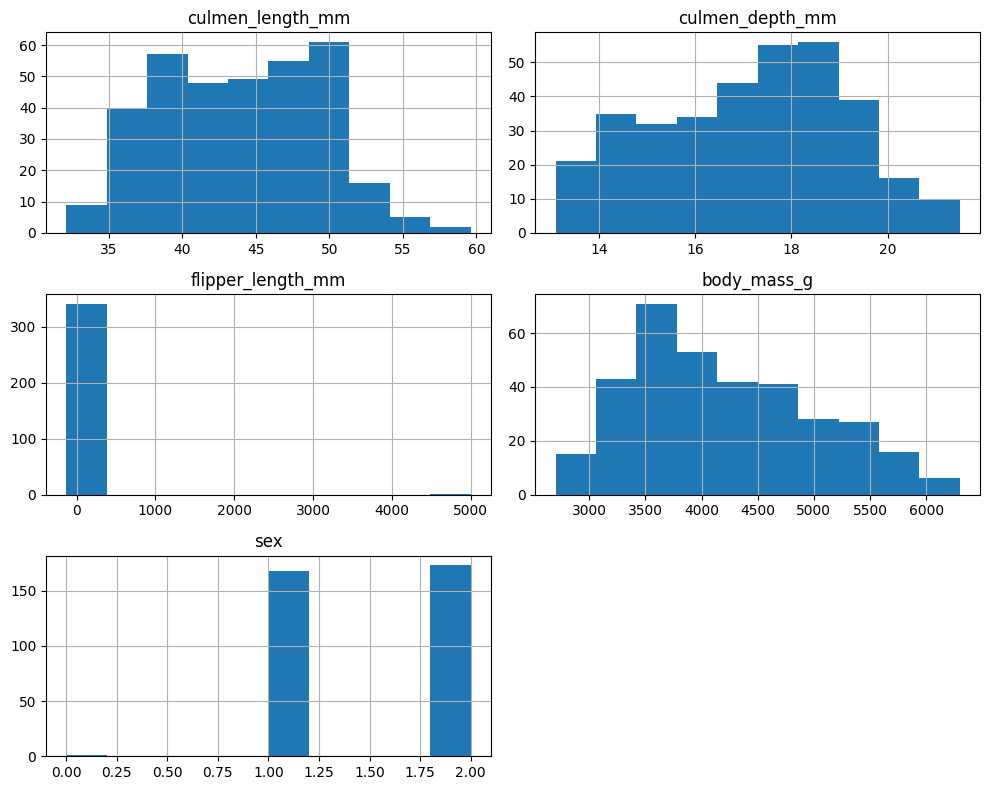

In [16]:
penguins_df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

In [17]:
penguins_df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
count,342.000000,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,214.014620,4201.754386,1.502924
std,5.459584,1.974793,260.558057,801.954536,0.506547
min,32.100000,13.100000,-132.000000,2700.000000,0.000000
25%,39.225000,15.600000,190.000000,3550.000000,1.000000
50%,44.450000,17.300000,197.000000,4050.000000,2.000000
75%,48.500000,18.700000,213.750000,4750.000000,2.000000
max,59.600000,21.500000,5000.000000,6300.000000,2.000000


In [18]:
penguins_df[penguins_df["flipper_length_mm"] > 4000]

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
9,42.0,20.2,5000.0,4250.0,2


In [19]:
penguins_df[penguins_df["flipper_length_mm"] < 0]

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
14,34.6,21.1,-132.0,4400.0,2


In [20]:
penguins_clean = penguins_df.drop([9, 14])

In [21]:
penguins_clean.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,2
1,39.5,17.4,186.0,3800.0,1
2,40.3,18.0,195.0,3250.0,1
4,36.7,19.3,193.0,3450.0,1
5,39.3,20.6,190.0,3650.0,2


In [22]:
penguins_clean.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
count,340.000000,340.000000,340.000000,340.000000,340.000000
mean,43.955000,17.130588,200.955882,4201.029412,1.500000
std,5.451108,1.961880,14.089719,804.240035,0.506594
min,32.100000,13.100000,172.000000,2700.000000,0.000000
25%,39.275000,15.575000,190.000000,3550.000000,1.000000
50%,44.500000,17.300000,197.000000,4025.000000,2.000000
75%,48.500000,18.625000,213.250000,4756.250000,2.000000
max,59.600000,21.500000,231.000000,6300.000000,2.000000


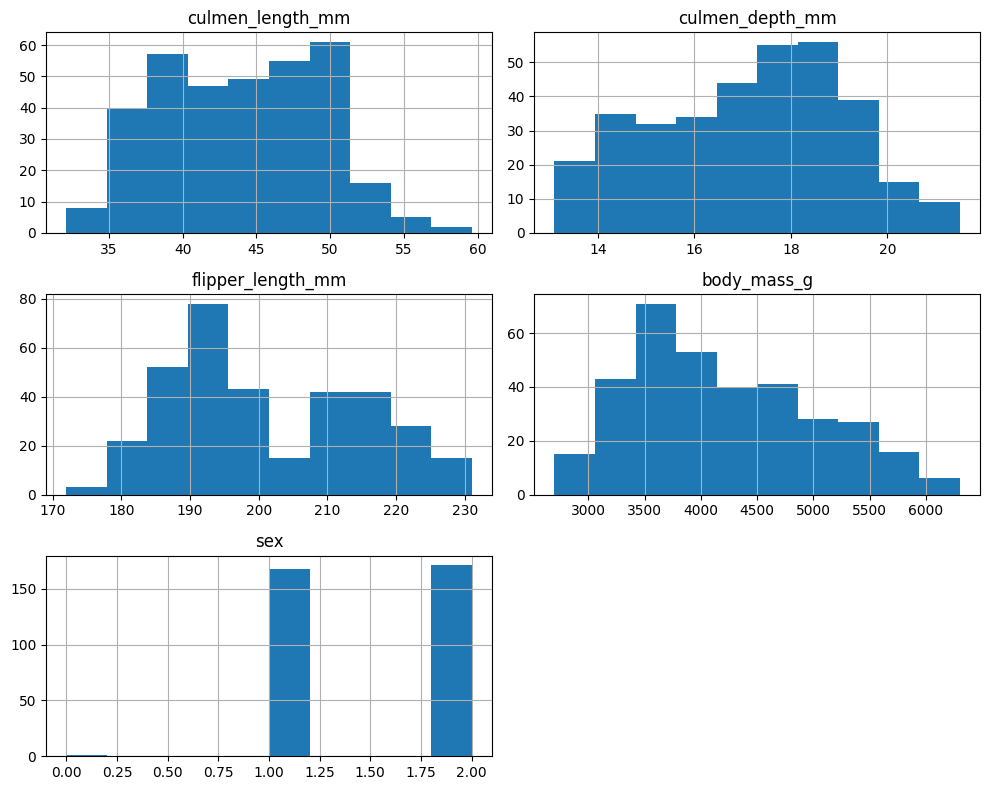

In [23]:
penguins_clean.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

In [24]:
scaler = StandardScaler()
X = scaler.fit_transform(penguins_clean)
penguins_preprocessed = pd.DataFrame(data=X, columns=penguins_clean.columns)
penguins_preprocessed.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,-0.891957,0.801132,-1.418431,-0.561641,0.988439
1,-0.818470,0.137526,-1.063039,-0.499379,-0.988439
2,-0.671494,0.443806,-0.423334,-1.184262,-0.988439
3,-1.332884,1.107412,-0.565491,-0.935214,-0.988439
4,-0.855213,1.771018,-0.778726,-0.686165,0.988439


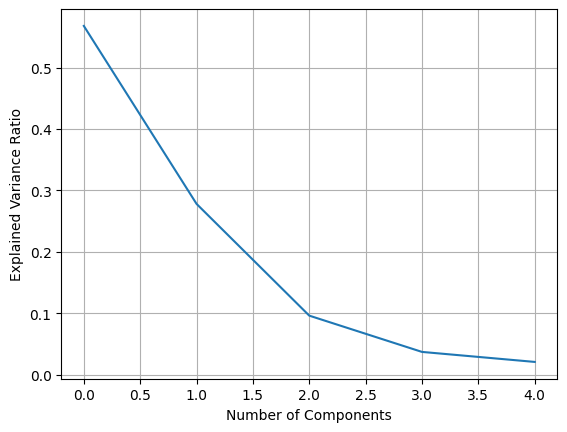

In [ ]:
pca = PCA(n_components=penguins_preprocessed.shape[1])

pca.fit(penguins_preprocessed)

explained_variance = pca.explained_variance_ratio_

plt.plot(explained_variance)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

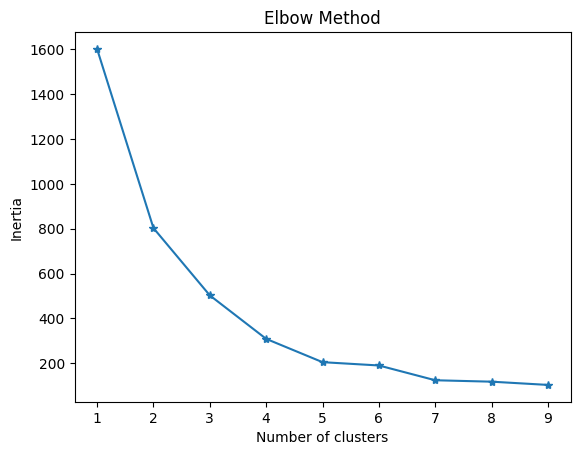

In [87]:
pca = PCA(n_components=3)
PCA_penguin = pca.fit_transform(penguins_preprocessed)


inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k,n_init='auto',random_state=42).fit(PCA_penguin)
    inertia.append(kmeans.inertia_)
plt.plot(range(1, 10), inertia, marker="*")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

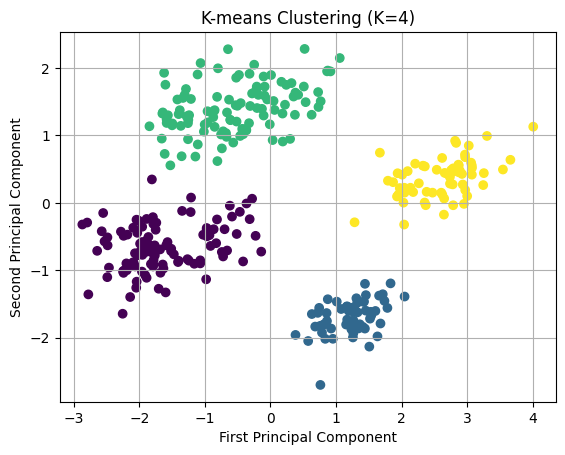

In [88]:
n_clusters = 4
kmeans = KMeans(n_clusters= n_clusters, n_init='auto',random_state=42).fit(PCA_penguin)

plt.scatter(PCA_penguin[:, 0], PCA_penguin[:, 1], c=kmeans.labels_, cmap="viridis")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title(f"K-means Clustering (K={n_clusters})")
plt.grid(True)
plt.show()

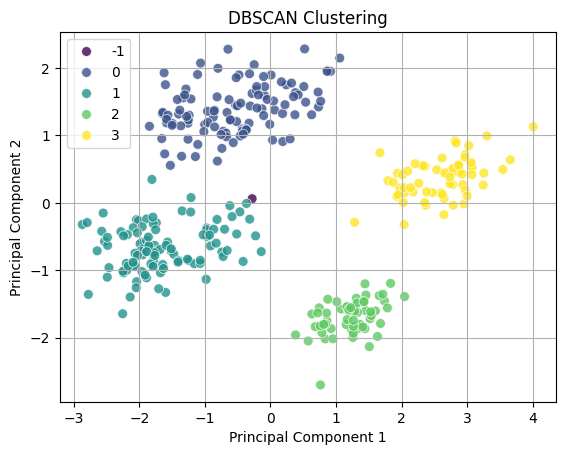

In [94]:
from sklearn.cluster import DBSCAN

eps = 1
min_samples = 6
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
clusters = dbscan.fit_predict(PCA_penguin)
cluster_labels = dbscan.labels_

sns.scatterplot(
    x=PCA_penguin[:, 0], 
    y=PCA_penguin[:, 1], 
    hue=clusters,        
    palette='viridis',   
    legend='full',       
    s=50,                
    alpha=0.8            
)

plt.title('DBSCAN Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

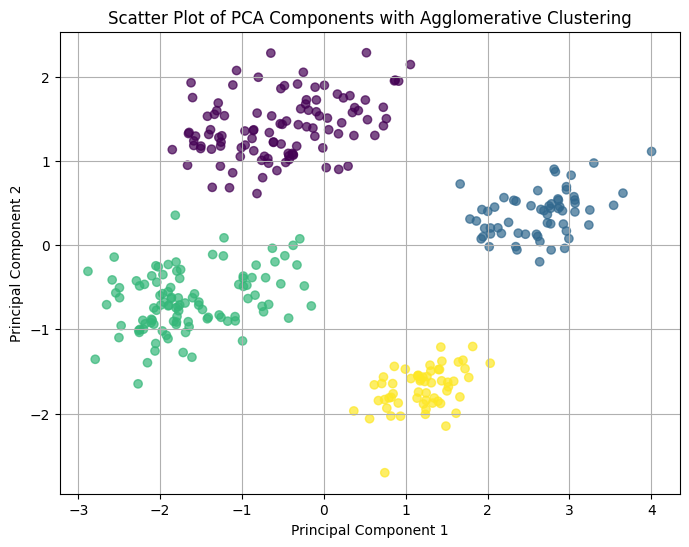

In [31]:
from sklearn.cluster import AgglomerativeClustering

ward_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward').fit(PCA_penguin)

cluster_labels = ward_clustering.labels_

# Prepare data for scatter plot with colors based on clusters
df_scatter = pd.DataFrame({'PC1': PCA_penguin[:, 0],
                           'PC2': PCA_penguin[:, 1],
                           'cluster': cluster_labels})

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df_scatter['PC1'], df_scatter['PC2'], c=cluster_labels,cmap="viridis", alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot of PCA Components with Agglomerative Clustering')
plt.grid(True)
plt.show()